# 고객 이탈 예측 (Telco Customer Churn)

## 1. 데이터 로딩 및 전처리

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 데이터 로딩
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# TotalCharges는 object → 숫자로 변환 + 결측치 처리
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)

# 'SeniorCitizen'은 숫자이지만 범주형으로 다루는 게 좋음
df["SeniorCitizen"] = df["SeniorCitizen"].astype("object")

# 이탈 여부 타겟 인코딩
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# 불필요한 컬럼 제거
df.drop(columns=["customerID"], inplace=True)

# 범주형 변수 인코딩
df_encoded = pd.get_dummies(df, drop_first=True)

# 특성과 타겟 분리
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

# 수치형 변수 스케일링
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 학습/검증 데이터 분할
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


C:\Users\shjun\AppData\Local\Temp\ipykernel_10888\3905132966.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


## 2. 기본 모델: 로지스틱 회귀

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)
preds = logreg.predict(X_val)

print("Logistic Regression")
print(f"Precision: {precision_score(y_val, preds):.4f}")
print(f"Recall: {recall_score(y_val, preds):.4f}")
print(f"F1 Score: {f1_score(y_val, preds):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, preds):.4f}")


Logistic Regression
Precision: 0.6831
Recall: 0.5952
F1 Score: 0.6361
ROC-AUC: 0.7479


## 3. 고급 모델: Random Forest, XGBoost, LightGBM

In [3]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    print(f"\n{name}")
    print(f"Precision: {precision_score(y_val, preds):.4f}")
    print(f"Recall: {recall_score(y_val, preds):.4f}")
    print(f"F1 Score: {f1_score(y_val, preds):.4f}")
    print(f"ROC-AUC: {roc_auc_score(y_val, preds):.4f}")



Random Forest
Precision: 0.6370
Recall: 0.4611
F1 Score: 0.5350
ROC-AUC: 0.6833


C:\Users\shjun\AppData\Roaming\Python\Python310\site-packages\xgboost\training.py:183: UserWarning: [15:48:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost
Precision: 0.6284
Recall: 0.4987
F1 Score: 0.5561
ROC-AUC: 0.6962
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001813 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 665
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.265531 -> initscore=-1.017418
[LightGBM] [Info] Start training from score -1.017418


C:\Users\shjun\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] 지정된 파일을 찾을 수 없습니다
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\shjun\AppData\Roaming\Python\Python310\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Program Files\Python310\lib\subprocess.py", line 501, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Program Files\Python310\lib\subprocess.py", line 969, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Program Files\Python310\lib\subprocess.py", line 1438, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,



LightGBM
Precision: 0.6644
Recall: 0.5147
F1 Score: 0.5801
ROC-AUC: 0.7106


C:\Users\shjun\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 4. 딥러닝 모델 (DNN)

In [4]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

import os
os.environ['CUDA_VISIBLE_DEVICES'] = '-1'

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_data=(X_val, y_val), verbose=0)

loss, acc = model.evaluate(X_val, y_val, verbose=0)
print(f"DNN Accuracy: {acc:.4f}")


DNN Accuracy: 0.8070


## 5. 학습 시각화 및 평가

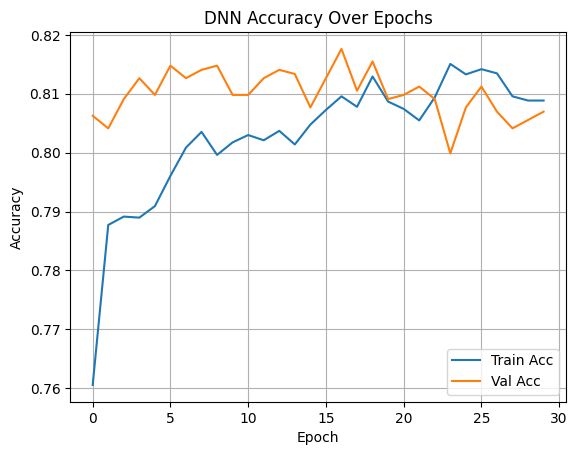

In [5]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("DNN Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()
